# Proyek Klasifikasi Gambar: [Input Nama Dataset]
- **Nama:** [Input Nama]
- **Email:** [Input Email]
- **ID Dicoding:** [Input Username]

## Import Semua Packages/Library yang Digunakan

In [1]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models


from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from glob import glob
from tqdm import tqdm

import tensorflow.keras.backend as K

import kagglehub
from kagglehub import KaggleDatasetAdapter

import os
import shutil

import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt


## Data Preparation

### Data Loading

In [2]:
!kaggle datasets download -d orvile/inme-veri-seti-stroke-dataset

Dataset URL: https://www.kaggle.com/datasets/orvile/inme-veri-seti-stroke-dataset
License(s): other
100% 991M/991M [00:03<00:00, 280MB/s]



In [3]:
!unzip -q inme-veri-seti-stroke-dataset.zip -d stroke_dataset

Proses ini menghasilkan struktur folder berdasarkan label kelas, yaitu:
* ‘İskemi/PNG’ untuk citra stroke iskemik,
* ‘Kanama/PNG’ untuk stroke hemoragik, dan
* ‘İnme Yok/PNG’ untuk citra normal.

### Data Preprocessing

#### 1. Membuat dataset baru

In [4]:
import os
import shutil

# path dataset asli
src_base = "stroke_dataset/İNME VERİ SETİ"

# path output baru
dst_base = "dataset_clean"

# mapping label
mapping = {
    "İnme Yok": "Normal",
    "İskemi": "Iskemik",
    "Kanama": "Hemoragik"
}

# ekstensi file
png_ext = (".png", ".jpg", ".jpeg")
overlay_ext = (".png", ".jpg", ".jpeg")  # biasanya overlay juga png

for src_folder, dst_folder in mapping.items():

    src_path = os.path.join(src_base, src_folder)

    if not os.path.exists(src_path):
        print(f"❌ Folder tidak ditemukan: {src_path}")
        continue

    # buat struktur folder tujuan
    dst_png = os.path.join(dst_base, dst_folder, "PNG")
    dst_overlay = os.path.join(dst_base, dst_folder, "OVERLAY")

    os.makedirs(dst_png, exist_ok=True)
    os.makedirs(dst_overlay, exist_ok=True)

    for root, dirs, files in os.walk(src_path):
        for file in files:

            src_file = os.path.join(root, file)
            file_lower = file.lower()

            # PNG IMAGE
            if file_lower.endswith(png_ext) and "overlay" not in root.lower():
                new_name = f"{dst_folder}_{file}"
                shutil.copy(src_file, os.path.join(dst_png, new_name))

            # OVERLAY / MASK
            elif file_lower.endswith(png_ext) and "overlay" in root.lower():
                new_name = f"{dst_folder}_{file}"
                shutil.copy(src_file, os.path.join(dst_overlay, new_name))

    print(f"✅ {dst_folder} selesai!")

print("Dataset clean berhasil dibuat dengan struktur lengkap!")

✅ Normal selesai!
✅ Iskemik selesai!
✅ Hemoragik selesai!
Dataset clean berhasil dibuat dengan struktur lengkap!


##### Melihat dataset PNG

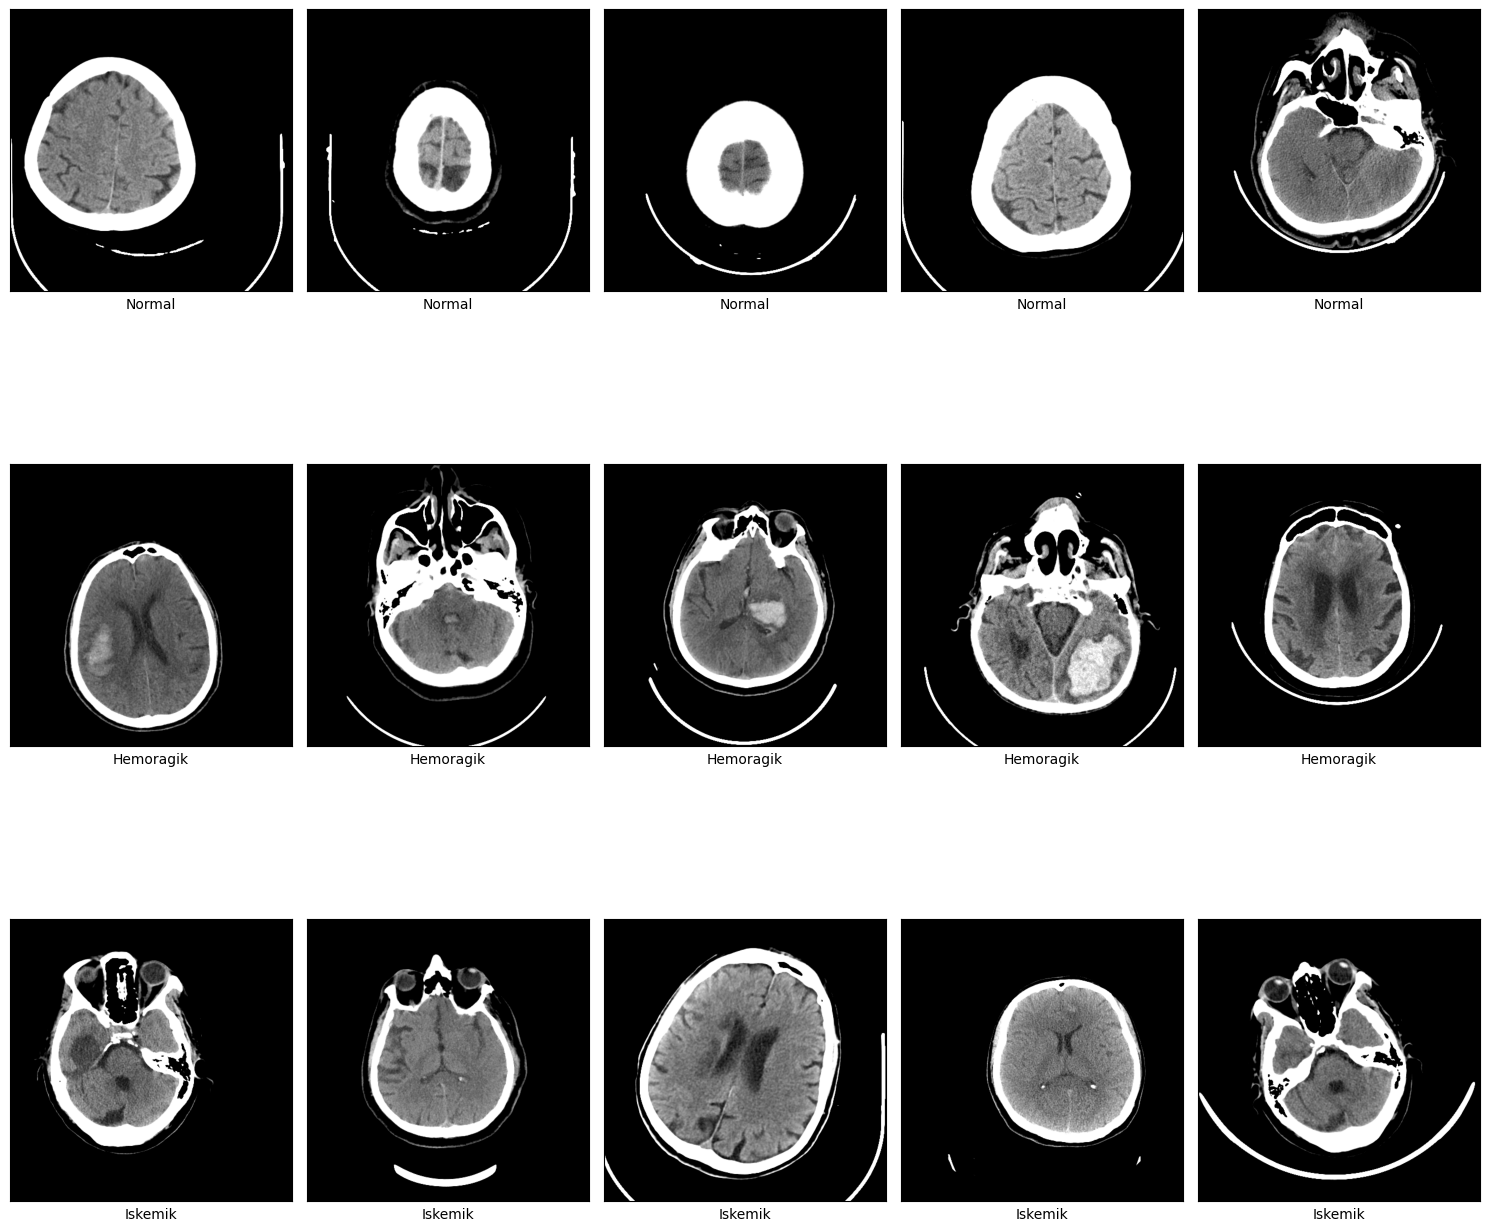

In [5]:
folder_dataset_base = "/content/dataset_clean"
png_dataset = {}

for class_name in os.listdir(folder_dataset_base):
    # The actual PNG images are in a 'PNG' subfolder within each class folder
    class_png_dir = os.path.join(folder_dataset_base, class_name, "PNG")
    if os.path.exists(class_png_dir):
        png_dataset[class_name] = [f for f in os.listdir(class_png_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# If no images are found, prevent further errors
if not png_dataset:
    print("No image data found to display. Please check the dataset path and structure.")
else:
    fig, axs = plt.subplots(len(png_dataset), 5, figsize=(15, 15))

    # Handle case where there's only one class to avoid indexing errors with axs
    if len(png_dataset) == 1:
        axs = np.expand_dims(axs, axis=0)

    for i, class_name in enumerate(png_dataset.keys()):
        # Ensure there are enough images to sample, or handle fewer than 5
        images_in_class = png_dataset[class_name]
        if not images_in_class:
            print(f"No images in class: {class_name}")
            # Set the axis to blank or display a message if no images
            for j in range(5):
                axs[i, j].set_visible(False) # Hide empty subplots
            continue

        num_samples = min(5, len(images_in_class))
        if num_samples == 0:
            print(f"Skipping class {class_name} due to no images.")
            # Set the axis to blank or display a message if no images
            for j in range(5):
                axs[i, j].set_visible(False) # Hide empty subplots
            continue

        images = np.random.choice(images_in_class, num_samples, replace=False)

        for j, image_name in enumerate(images):
            img_path = os.path.join(folder_dataset_base, class_name, "PNG", image_name)
            try:
                img = Image.open(img_path)
                axs[i, j].imshow(img)
                axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])
            except FileNotFoundError:
                print(f"Error: Image file not found at {img_path}")
                axs[i, j].set_visible(False)
            except Exception as e:
                print(f"Error opening image {img_path}: {e}")
                axs[i, j].set_visible(False)

        # If fewer than 5 images were displayed, hide the remaining subplots in the row
        for j in range(num_samples, 5):
            axs[i, j].set_visible(False)

    fig.tight_layout()

##### Melihat dataset OVERLAY

No images in class: Normal


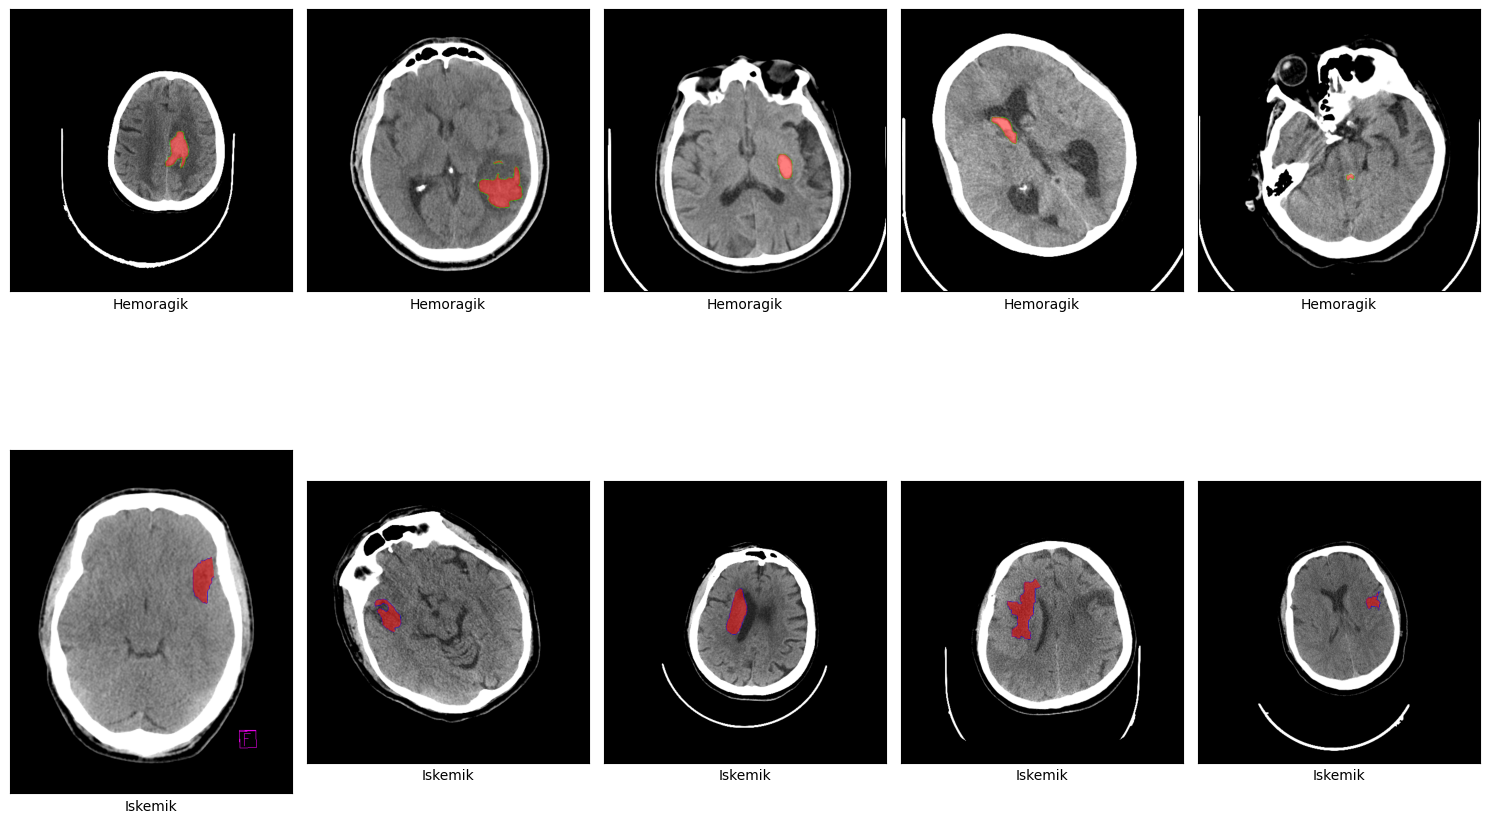

In [6]:
folder_dataset_base = "/content/dataset_clean"
overlay_dataset = {}

for class_name in os.listdir(folder_dataset_base):
    # The actual overlay images are in a 'overlay' subfolder within each class folder
    overlay_dir = os.path.join(folder_dataset_base, class_name, "OVERLAY")
    if os.path.exists(overlay_dir):
        overlay_dataset[class_name] = [f for f in os.listdir(overlay_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# If no images are found, prevent further errors
if not overlay_dataset:
    print("No image data found to display. Please check the dataset path and structure.")
else:
    fig, axs = plt.subplots(len(overlay_dataset), 5, figsize=(15, 15))

    # Handle case where there's only one class to avoid indexing errors with axs
    if len(overlay_dataset) == 1:
        axs = np.expand_dims(axs, axis=0)

    for i, class_name in enumerate(overlay_dataset.keys()):
        # Ensure there are enough images to sample, or handle fewer than 5
        images_in_class = overlay_dataset[class_name]
        if not images_in_class:
            print(f"No images in class: {class_name}")
            # Set the axis to blank or display a message if no images
            for j in range(5):
                axs[i, j].set_visible(False) # Hide empty subplots
            continue

        num_samples = min(5, len(images_in_class))
        if num_samples == 0:
            print(f"Skipping class {class_name} due to no images.")
            # Set the axis to blank or display a message if no images
            for j in range(5):
                axs[i, j].set_visible(False) # Hide empty subplots
            continue

        images = np.random.choice(images_in_class, num_samples, replace=False)

        for j, image_name in enumerate(images):
            img_path = os.path.join(folder_dataset_base, class_name, "OVERLAY", image_name)
            try:
                img = Image.open(img_path)
                axs[i, j].imshow(img)
                axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])
            except FileNotFoundError:
                print(f"Error: Image file not found at {img_path}")
                axs[i, j].set_visible(False)
            except Exception as e:
                print(f"Error opening image {img_path}: {e}")
                axs[i, j].set_visible(False)

        # If fewer than 5 images were displayed, hide the remaining subplots in the row
        for j in range(num_samples, 5):
            axs[i, j].set_visible(False)

    fig.tight_layout()

Setiap gambar akan dibaca dan disimpan ke dalam DataFrame berisi:
- Path lengkap file
- Label klasifikasi:
  * ‘İskemi/PNG’ untuk citra stroke iskemik,
  * ‘Kanama/PNG’ untuk stroke hemoragik, dan
  * ‘İnme Yok/PNG’ untuk citra normal.

#### Undersampling

In [7]:
import os
import random
import shutil
import cv2
import numpy as np

base_dir = "dataset_clean"
output_dir = "dataset_balanced"

classes = ["Hemoragik", "Iskemik", "Normal"]
TARGET_PER_CLASS = 1000
IMG_SIZE = (224, 224)

for cls in classes:
    print(f"\n📂 Processing {cls}")

    img_dir = os.path.join(base_dir, cls, "PNG")
    mask_dir = os.path.join(base_dir, cls, "OVERLAY")

    out_img_dir = os.path.join(output_dir, cls, "PNG")
    out_mask_dir = os.path.join(output_dir, cls, "OVERLAY")

    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_mask_dir, exist_ok=True)

    img_files = os.listdir(img_dir)

    # CASE 1: ADA MASK
    if os.path.exists(mask_dir) and len(os.listdir(mask_dir)) > 0:
        mask_files = set(os.listdir(mask_dir))
        img_files = set(img_files)

        common_files = list(img_files & mask_files)

    # CASE 2: NORMAL (NO MASK)
    else:
        common_files = img_files

    print("Total data:", len(common_files))

    # undersampling
    if len(common_files) < TARGET_PER_CLASS:
        selected = common_files
    else:
        selected = random.sample(common_files, TARGET_PER_CLASS)

    for fname in selected:
        img_path = os.path.join(img_dir, fname)
        out_img_path = os.path.join(out_img_dir, fname)

        # copy image
        shutil.copy(img_path, out_img_path)

        # MASK HANDLING
        if cls == "Normal":
            # bikin mask kosong
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, IMG_SIZE)

            blank_mask = np.zeros_like(img)

            cv2.imwrite(os.path.join(out_mask_dir, fname), blank_mask)

        else:
            # copy mask biasa
            shutil.copy(
                os.path.join(mask_dir, fname),
                os.path.join(out_mask_dir, fname)
            )

    print(f"✅ {cls} selesai:", len(selected))


📂 Processing Hemoragik
Total data: 1093
✅ Hemoragik selesai: 1000

📂 Processing Iskemik
Total data: 1130
✅ Iskemik selesai: 1000

📂 Processing Normal
Total data: 4551
✅ Normal selesai: 1000


####  Menggabungkan dataset PNG dan OVERLAY



In [8]:
def get_paths(base_dir):
    image_paths = []
    mask_paths = []
    labels = []

    classes = ["Normal", "Hemoragik", "Iskemik"]

    for cls in classes:
        img_dir = os.path.join(base_dir, cls, "PNG")

        if cls != "Normal":
            mask_dir = os.path.join(base_dir, cls, "OVERLAY")
        else:
            mask_dir = None

        for file in os.listdir(img_dir):
            if file.endswith(".png"):
                image_paths.append(os.path.join(img_dir, file))

                if mask_dir:
                    mask_paths.append(os.path.join(mask_dir, file))
                else:
                    mask_paths.append(None)

                labels.append(cls)

    return image_paths, mask_paths, labels

#### Segmentasi

In [9]:
def preprocess(img_path, mask_path, size=(224,224)):

    img = cv2.imread(img_path)
    img = cv2.resize(img, size)
    img = img / 255.0   # RGB langsung

    if mask_path is not None and os.path.exists(mask_path):
        mask = cv2.imread(mask_path)
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2HSV)

        lower1 = np.array([0,100,100])
        upper1 = np.array([10,255,255])
        lower2 = np.array([160,100,100])
        upper2 = np.array([180,255,255])

        m1 = cv2.inRange(mask, lower1, upper1)
        m2 = cv2.inRange(mask, lower2, upper2)

        mask = m1 + m2
        mask = cv2.resize(mask, size)
        mask = mask / 255.0
    else:
        mask = np.zeros(size)

    mask = np.expand_dims(mask, axis=-1)

    return img, mask

In [10]:
def apply_mask(img, mask):
    return img * mask   # broadcast ke 3 channel

#### Labeling

In [11]:
from tensorflow.keras.utils import to_categorical

label_map = {"Normal":0, "Hemoragik":1, "Iskemik":2}

def encode_labels(labels):
    y = [label_map[l] for l in labels]
    return to_categorical(y, num_classes=3)

#### Build Dataset

In [12]:
def build_dataset(img_paths, mask_paths, labels):
    X = []
    y = []

    for img_path, mask_path, label in zip(img_paths, mask_paths, labels):
        img, mask = preprocess(img_path, mask_path)

        masked_img = apply_mask(img, mask)

        X.append(masked_img)
        y.append(label_map[label])

    X = np.array(X, dtype=np.float32)
    y = to_categorical(y, num_classes=3)

    return X, y

#### Split Dataset

In [13]:
base_dir = "/content/dataset_balanced"

img_paths, mask_paths, labels = get_paths(base_dir)

train_img, test_img, train_mask, test_mask, train_lbl, test_lbl = train_test_split(
    img_paths, mask_paths, labels, test_size=0.2, random_state=42, stratify=labels
)

X_train, y_train = build_dataset(train_img, train_mask, train_lbl)
X_test, y_test = build_dataset(test_img, test_mask, test_lbl)

## Modelling

In [14]:
def build_mobilenet():

    base_model = MobileNetV2(
        input_shape=(224,224,3),
        include_top=False,
        weights='imagenet'
    )

    base_model.trainable = False

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(3, activation='softmax')(x)

    model = models.Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [15]:
model = build_mobilenet()

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=8
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 0.8875 - loss: 0.2710 - val_accuracy: 0.9167 - val_loss: 0.1713
Epoch 2/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9356 - loss: 0.1472 - val_accuracy: 0.9583 - val_loss: 0.1271
Epoch 3/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9495 - loss: 0.1145 - val_accuracy: 0.9625 - val_loss: 0.1227
Epoch 4/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9593 - loss: 0.1072 - val_accuracy: 0.9583 - val_loss: 0.1163
Epoch 5/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9602 - loss: 0.0966 - val_accuracy: 0.9667 - val_loss: 0.1314
Epoch 6/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9718 - loss: 0.0719 - val_accuracy: 0.9583 - val_loss: 0.1224
Epoch 7/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9810 - loss: 0.0581 - val_accuracy: 0.9583 - val_loss: 0.1485
Epoch 8/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms

## Evaluasi dan Visualisasi

19/19 ━━━━━━━━━━━━━━━━━━━━ 26s 735ms/step


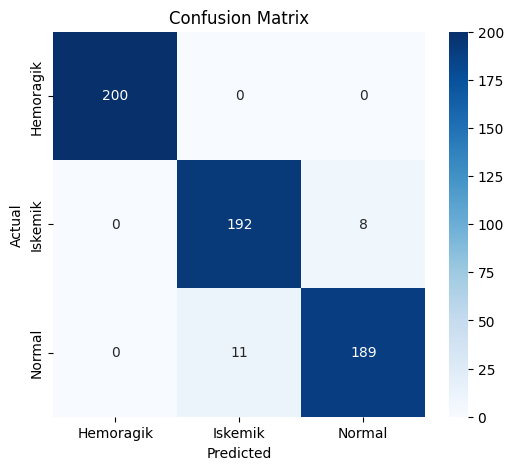

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# prediksi
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Hemoragik","Iskemik","Normal"],
            yticklabels=["Hemoragik","Iskemik","Normal"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [17]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true, y_pred,
    target_names=["Normal","Hemoragik","Iskemik"]
))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       200
   Hemoragik       0.95      0.96      0.95       200
     Iskemik       0.96      0.94      0.95       200

    accuracy                           0.97       600
   macro avg       0.97      0.97      0.97       600
weighted avg       0.97      0.97      0.97       600



## Konversi Model

In [18]:
# SAVE CLASSIFICATION MODEL (.keras)
model.save('/content/klas_model.keras')

from google.colab import files
files.download('/content/klas_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
# Simpan label kelas ke file teks
class_labels = [
    "Normal", "Hemoragik", "Iskemik"
]

with open('custom_model_labels.txt', 'w') as f:
    for label in class_labels:
        f.write(f"{label}\n")

print("Label kelas disimpan ke 'custom_model_labels.txt'")

Label kelas disimpan ke 'custom_model_labels.txt'


## Inference (Optional)

✅ Segmentation + Classification Model Loaded


Saving Iskemik_10003.png to Iskemik_10003.png

🔍 Processing: Iskemik_10003.png
🧠 Prediction : Iskemik
📊 Confidence : 0.994857668876648


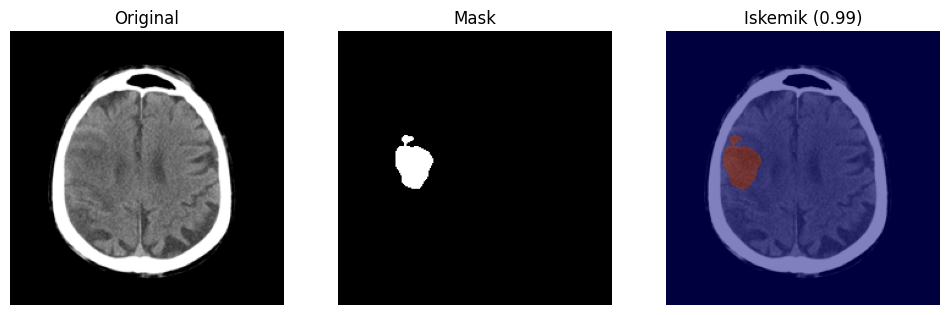

In [23]:
# =========================
# 1. IMPORT
# =========================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
import cv2
import tensorflow.keras.backend as K

# =========================
# Custom Loss Functions (needed for seg_model)
# =========================
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    return tf.keras.losses.binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)

def iou(y_true, y_pred):
    smooth = 1e-6
    intersection = K.sum(y_true * y_pred)
    return (intersection + smooth) / (K.sum(y_true + y_pred) - intersection + smooth)

# =========================
# 2. LOAD MODEL (FIXED)
# =========================
# Provide custom_objects dictionary when loading the model
seg_model = tf.keras.models.load_model(
    "/content/seg_model (5).keras", # Corrected filename
    custom_objects={'bce_dice_loss': bce_dice_loss, 'dice_coef': dice_coef, 'dice_loss': dice_loss, 'iou': iou}
)
cls_model = tf.keras.models.load_model("/content/klas_model.keras")

print("✅ Segmentation + Classification Model Loaded")

# =========================
# 3. LABEL
# =========================
class_labels = ["Normal", "Hemoragik", "Iskemik"]

# =========================
# 4. PREPROCESS
# =========================
def prepare_image(img_path, size=(224, 224)):
    # Change 'L' to 'RGB' to ensure 3 channels
    img = Image.open(img_path).convert('RGB')
    img = img.resize(size)

    img_array = np.array(img, dtype=np.float32) / 255.0

    # No need to expand dims for channels, as 'RGB' already provides 3 channels
    # pastikan shape (1,H,W,C)
    img_array = np.expand_dims(img_array, axis=0)

    return img, img_array

# =========================
# 5. UPLOAD
# =========================
uploaded = files.upload()

# =========================
# 6. INFERENCE
# =========================
for filename in uploaded.keys():
    print(f"\n🔍 Processing: {filename}")

    img, img_array = prepare_image(filename)

    # ======================
    # SEGMENTATION (FIXED)
    # ======================
    pred_mask = seg_model.predict(img_array, verbose=0)[0]

    if pred_mask.shape[-1] == 1:
        pred_mask = pred_mask.squeeze()

    pred_mask = (pred_mask > 0.3).astype(np.uint8)
    pred_mask = cv2.medianBlur(pred_mask, 5)

    # ======================
    # APPLY MASK
    # ======================
    # Original img_array[0] now has 3 channels, so no need for np.repeat
    masked_img = img_array[0] * np.expand_dims(pred_mask, axis=-1)

    # Ensure masked_img is 3 channels if it somehow becomes 1 after multiplication with mask
    if masked_img.shape[-1] == 1: # This case might occur if pred_mask was (224,224) and img_array[0] was (224,224,1)
        masked_img = np.repeat(masked_img, 3, axis=-1)

    masked_img = cv2.resize(masked_img, (224, 224))
    masked_img = np.expand_dims(masked_img, axis=0)

    # ======================
    # CLASSIFICATION
    # ======================
    pred_cls = cls_model.predict(masked_img, verbose=0)

    idx = np.argmax(pred_cls)
    label = class_labels[idx]
    confidence = float(pred_cls[0][idx])

    # ======================
    # VISUALISASI
    # ======================
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    # When displaying original 'img', use cmap if it was single channel. Now it's RGB so no cmap needed.
    plt.imshow(img)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(pred_mask, cmap='gray')
    plt.title("Mask")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(img)
    plt.imshow(pred_mask, cmap='jet', alpha=0.5)
    plt.title(f"{label} ({confidence:.2f})")
    plt.axis('off')

    print("🧠 Prediction :", label)
    print("📊 Confidence :", confidence)
    plt.show()

✅ Segmentation + Classification Model Loaded


Saving Hemoragik_10002.png to Hemoragik_10002.png

🔍 Processing: Hemoragik_10002.png


🧠 Prediction : Hemoragik
📊 Confidence : 0.9999488592147827


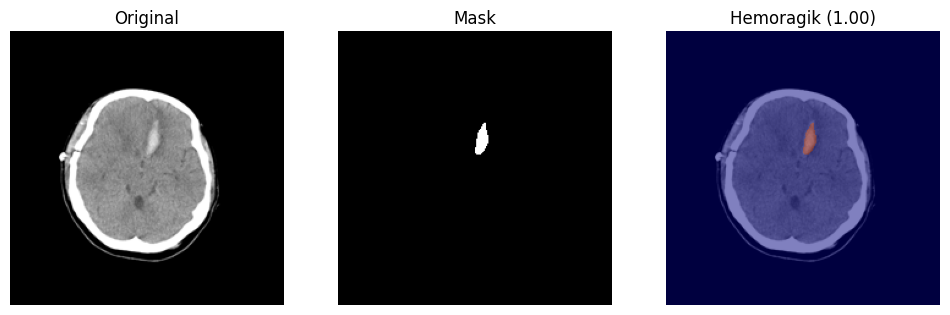

In [24]:
# =========================
# 1. IMPORT
# =========================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
import cv2
import tensorflow.keras.backend as K

# =========================
# Custom Loss Functions (needed for seg_model)
# =========================
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    return tf.keras.losses.binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)

def iou(y_true, y_pred):
    smooth = 1e-6
    intersection = K.sum(y_true * y_pred)
    return (intersection + smooth) / (K.sum(y_true + y_pred) - intersection + smooth)

# =========================
# 2. LOAD MODEL (FIXED)
# =========================
# Provide custom_objects dictionary when loading the model
seg_model = tf.keras.models.load_model(
    "/content/seg_model (5).keras", # Corrected filename
    custom_objects={'bce_dice_loss': bce_dice_loss, 'dice_coef': dice_coef, 'dice_loss': dice_loss, 'iou': iou}
)
cls_model = tf.keras.models.load_model("/content/klas_model.keras")

print("✅ Segmentation + Classification Model Loaded")

# =========================
# 3. LABEL
# =========================
class_labels = ["Normal", "Hemoragik", "Iskemik"]

# =========================
# 4. PREPROCESS
# =========================
def prepare_image(img_path, size=(224, 224)):
    # Change 'L' to 'RGB' to ensure 3 channels
    img = Image.open(img_path).convert('RGB')
    img = img.resize(size)

    img_array = np.array(img, dtype=np.float32) / 255.0

    # No need to expand dims for channels, as 'RGB' already provides 3 channels
    # pastikan shape (1,H,W,C)
    img_array = np.expand_dims(img_array, axis=0)

    return img, img_array

# =========================
# 5. UPLOAD
# =========================
uploaded = files.upload()

# =========================
# 6. INFERENCE
# =========================
for filename in uploaded.keys():
    print(f"\n🔍 Processing: {filename}")

    img, img_array = prepare_image(filename)

    # ======================
    # SEGMENTATION (FIXED)
    # ======================
    pred_mask = seg_model.predict(img_array, verbose=0)[0]

    if pred_mask.shape[-1] == 1:
        pred_mask = pred_mask.squeeze()

    pred_mask = (pred_mask > 0.3).astype(np.uint8)
    pred_mask = cv2.medianBlur(pred_mask, 5)

    # ======================
    # APPLY MASK
    # ======================
    # Original img_array[0] now has 3 channels, so no need for np.repeat
    masked_img = img_array[0] * np.expand_dims(pred_mask, axis=-1)

    # Ensure masked_img is 3 channels if it somehow becomes 1 after multiplication with mask
    if masked_img.shape[-1] == 1: # This case might occur if pred_mask was (224,224) and img_array[0] was (224,224,1)
        masked_img = np.repeat(masked_img, 3, axis=-1)

    masked_img = cv2.resize(masked_img, (224, 224))
    masked_img = np.expand_dims(masked_img, axis=0)

    # ======================
    # CLASSIFICATION
    # ======================
    pred_cls = cls_model.predict(masked_img, verbose=0)

    idx = np.argmax(pred_cls)
    label = class_labels[idx]
    confidence = float(pred_cls[0][idx])

    # ======================
    # VISUALISASI
    # ======================
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    # When displaying original 'img', use cmap if it was single channel. Now it's RGB so no cmap needed.
    plt.imshow(img)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(pred_mask, cmap='gray')
    plt.title("Mask")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(img)
    plt.imshow(pred_mask, cmap='jet', alpha=0.5)
    plt.title(f"{label} ({confidence:.2f})")
    plt.axis('off')

    print("🧠 Prediction :", label)
    print("📊 Confidence :", confidence)
    plt.show()

✅ Segmentation + Classification Model Loaded


Saving Normal_10000.png to Normal_10000.png

🔍 Processing: Normal_10000.png
🧠 Prediction : Normal
📊 Confidence : 1.0


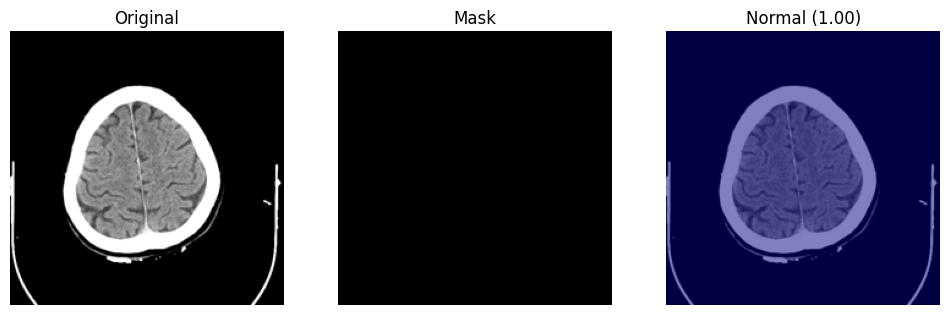

In [25]:
# =========================
# 1. IMPORT
# =========================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
import cv2
import tensorflow.keras.backend as K

# =========================
# Custom Loss Functions (needed for seg_model)
# =========================
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    return tf.keras.losses.binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)

def iou(y_true, y_pred):
    smooth = 1e-6
    intersection = K.sum(y_true * y_pred)
    return (intersection + smooth) / (K.sum(y_true + y_pred) - intersection + smooth)

# =========================
# 2. LOAD MODEL (FIXED)
# =========================
# Provide custom_objects dictionary when loading the model
seg_model = tf.keras.models.load_model(
    "/content/seg_model (5).keras", # Corrected filename
    custom_objects={'bce_dice_loss': bce_dice_loss, 'dice_coef': dice_coef, 'dice_loss': dice_loss, 'iou': iou}
)
cls_model = tf.keras.models.load_model("/content/klas_model.keras")

print("✅ Segmentation + Classification Model Loaded")

# =========================
# 3. LABEL
# =========================
class_labels = ["Normal", "Hemoragik", "Iskemik"]

# =========================
# 4. PREPROCESS
# =========================
def prepare_image(img_path, size=(224, 224)):
    # Change 'L' to 'RGB' to ensure 3 channels
    img = Image.open(img_path).convert('RGB')
    img = img.resize(size)

    img_array = np.array(img, dtype=np.float32) / 255.0

    # No need to expand dims for channels, as 'RGB' already provides 3 channels
    # pastikan shape (1,H,W,C)
    img_array = np.expand_dims(img_array, axis=0)

    return img, img_array

# =========================
# 5. UPLOAD
# =========================
uploaded = files.upload()

# =========================
# 6. INFERENCE
# =========================
for filename in uploaded.keys():
    print(f"\n🔍 Processing: {filename}")

    img, img_array = prepare_image(filename)

    # ======================
    # SEGMENTATION (FIXED)
    # ======================
    pred_mask = seg_model.predict(img_array, verbose=0)[0]

    if pred_mask.shape[-1] == 1:
        pred_mask = pred_mask.squeeze()

    pred_mask = (pred_mask > 0.3).astype(np.uint8)
    pred_mask = cv2.medianBlur(pred_mask, 5)

    # ======================
    # APPLY MASK
    # ======================
    # Original img_array[0] now has 3 channels, so no need for np.repeat
    masked_img = img_array[0] * np.expand_dims(pred_mask, axis=-1)

    # Ensure masked_img is 3 channels if it somehow becomes 1 after multiplication with mask
    if masked_img.shape[-1] == 1: # This case might occur if pred_mask was (224,224) and img_array[0] was (224,224,1)
        masked_img = np.repeat(masked_img, 3, axis=-1)

    masked_img = cv2.resize(masked_img, (224, 224))
    masked_img = np.expand_dims(masked_img, axis=0)

    # ======================
    # CLASSIFICATION
    # ======================
    pred_cls = cls_model.predict(masked_img, verbose=0)

    idx = np.argmax(pred_cls)
    label = class_labels[idx]
    confidence = float(pred_cls[0][idx])

    # ======================
    # VISUALISASI
    # ======================
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    # When displaying original 'img', use cmap if it was single channel. Now it's RGB so no cmap needed.
    plt.imshow(img)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(pred_mask, cmap='gray')
    plt.title("Mask")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(img)
    plt.imshow(pred_mask, cmap='jet', alpha=0.5)
    plt.title(f"{label} ({confidence:.2f})")
    plt.axis('off')

    print("🧠 Prediction :", label)
    print("📊 Confidence :", confidence)
    plt.show()